In [1]:
# pip install pandas numpy matplotlib seaborn scipy scikit-learn xgboost tensorflow

In [2]:
# !brew install libomp 

## 1. Setup & Data 

In [3]:
## 1.1 Imports & Setup
import os, warnings, random, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from scipy import stats as scipy_stats
from statsmodels.tsa.stattools import adfuller

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, GRU, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
os.environ['PYTHONHASHSEED'] = str(RANDOM_STATE)
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

plt.rcParams.update({
    'figure.dpi': 120, 'font.size': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3,
})
COLORS = ['#378ADD', '#1D9E75', '#BA7517', '#D85A30', '#7F77DD', '#C44B8A']

FEATURES  = ['Last Price', 'Volume', 'USD_Index', 'EFFR', 'Crude_Oil']
WINDOW    = 60    
TEST_SIZE = 300
VAL_RATIO = 0.15 
EPOCHS    = 50
BATCH     = 32
PATIENCE  = 10

print("✓ 1.1 Setup complete.")

✓ 1.1 Setup complete.


In [ ]:
## 1.2 Data Loading & Integration
df = pd.read_csv('Data/Processed/Cleaned_Multivariate_Data.csv')
df['Date'] = pd.to_datetime(df['Date'])

print(f"Dataset: {df.shape}  |  {df['Date'].min().date()} → {df['Date'].max().date()}")
display(df.head()) 

Dataset: (4603, 6)  |  2008-01-14 → 2026-01-28


,Date,Last Price,Volume,USD_Index,EFFR,Crude_Oil
0,2008-01-14,2051.0,0.0,89.2749,4.24,94.23
1,2008-01-15,2036.0,0.0,89.1555,4.24,91.87
2,2008-01-16,2040.0,0.0,89.6701,4.22,90.80
3,2008-01-17,2037.0,0.0,89.6484,4.23,90.11
4,2008-01-18,2027.0,0.0,89.8993,4.17,90.55


## 2. Exploratory Data Analysis (EDA)


In [5]:
# 2.1 Descriptive Statistics (Pure Train Isolation)
N_GROSS_ROWS = len(df) - TEST_SIZE                
df_eda = df.iloc[:N_GROSS_ROWS].copy()

print(f"EDA isolation: {len(df_eda)} rows  "
      f"({df_eda['Date'].min().date()} → {df_eda['Date'].max().date()})")

print("\n=== Descriptive Statistics (Pure Train) ===")
display(df_eda[FEATURES].describe().round(2))

EDA isolation: 4303 rows  (2008-01-14 → 2024-11-19)

=== Descriptive Statistics (Pure Train) ===


,Last Price,Volume,USD_Index,EFFR,Crude_Oil
count,4303.00,4303.00,4303.00,4303.00,4303.00
mean,1943.31,5694.32,106.06,1.17,73.05
std,615.70,4694.90,12.09,1.63,22.75
min,1121.00,0.00,85.47,0.04,-36.98
25%,1548.00,430.00,93.42,0.10,53.41
50%,1864.00,5650.00,110.38,0.19,73.24
75%,2134.00,8530.00,116.00,1.91,91.09
max,5334.00,45910.00,128.45,5.33,145.31


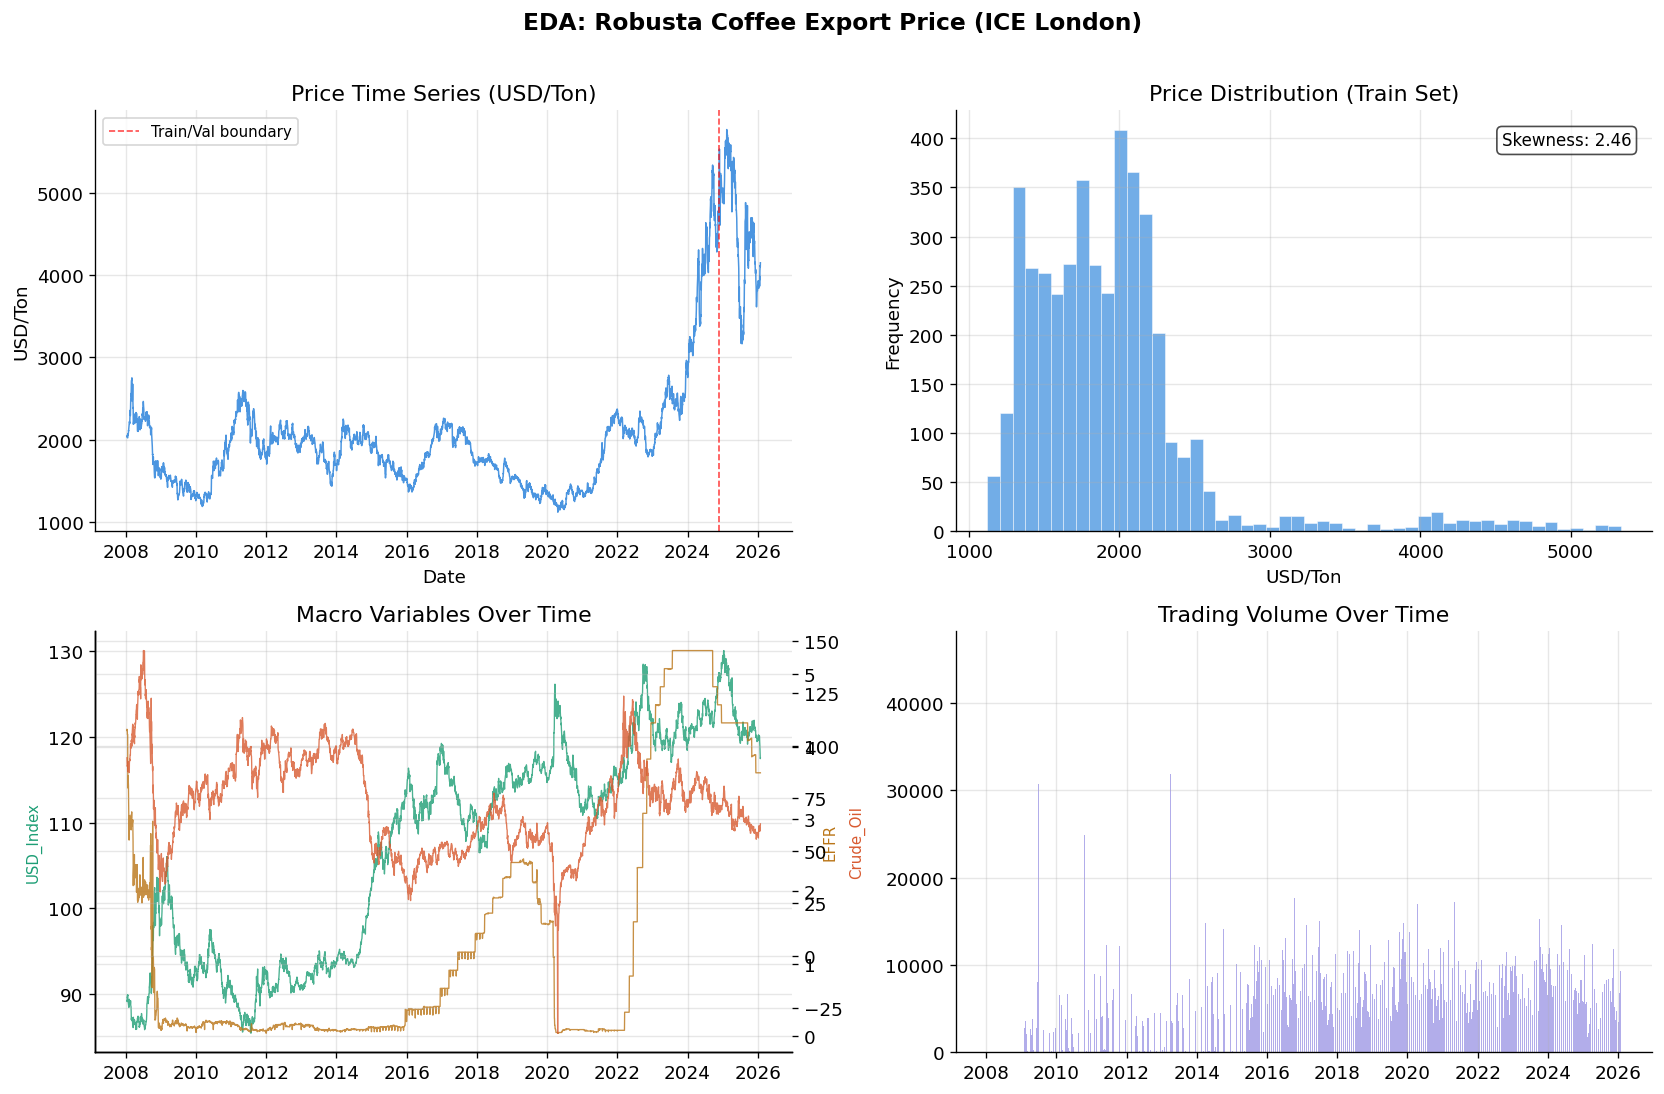

In [6]:
## 2.2 Price Overview & Distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('EDA: Robusta Coffee Export Price (ICE London)',
             fontsize=14, fontweight='bold', y=1.01)

ax = axes[0,0]
ax.plot(df['Date'], df['Last Price'], color=COLORS[0], lw=0.9, alpha=0.9)
ax.axvline(df_eda['Date'].iloc[-1], color='red', ls='--', lw=1,
           alpha=0.7, label='Train/Val boundary')
ax.set_title('Price Time Series (USD/Ton)')
ax.set_xlabel('Date'); ax.set_ylabel('USD/Ton')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(fontsize=9)

ax = axes[0,1]
ax.hist(df_eda['Last Price'], bins=50, color=COLORS[0], alpha=0.7,
        edgecolor='white', lw=0.4)
ax.set_title('Price Distribution (Train Set)')
ax.set_xlabel('USD/Ton'); ax.set_ylabel('Frequency')
skew = df_eda['Last Price'].skew()
ax.text(0.97, 0.95, f'Skewness: {skew:.2f}', transform=ax.transAxes,
        ha='right', va='top', fontsize=10,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

ax = axes[1,0]
for i, col in enumerate(['USD_Index','EFFR','Crude_Oil']):
    ax2 = ax if i == 0 else ax.twinx()
    ax2.plot(df['Date'], df[col], color=COLORS[i+1], lw=0.8, alpha=0.8, label=col)
    ax2.set_ylabel(col, color=COLORS[i+1], fontsize=9)
ax.set_title('Macro Variables Over Time')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

ax = axes[1,1]
ax.bar(df['Date'], df['Volume'], color=COLORS[4], alpha=0.6, width=1)
ax.set_title('Trading Volume Over Time')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('eda_price_overview.png', bbox_inches='tight', dpi=120)
plt.show()

In [7]:
## 2.3 ADF Stationarity Test
print("\n=== ADF Stationarity Test (Train Set) ===")
for label, series in [('Level', df_eda['Last Price']),
                      ('1st Diff', df_eda['Last Price'].diff().dropna())]:
    r = adfuller(series)
    concl = "Stationary ✓" if r[1] < 0.05 else "Non-Stationary ✗"
    print(f"  [{label}]  ADF={r[0]:.4f}  p={r[1]:.4f}  → {concl}")


=== ADF Stationarity Test (Train Set) ===
  [Level]  ADF=1.1707  p=0.9958  → Non-Stationary ✗
  [1st Diff]  ADF=-16.7177  p=0.0000  → Stationary ✓


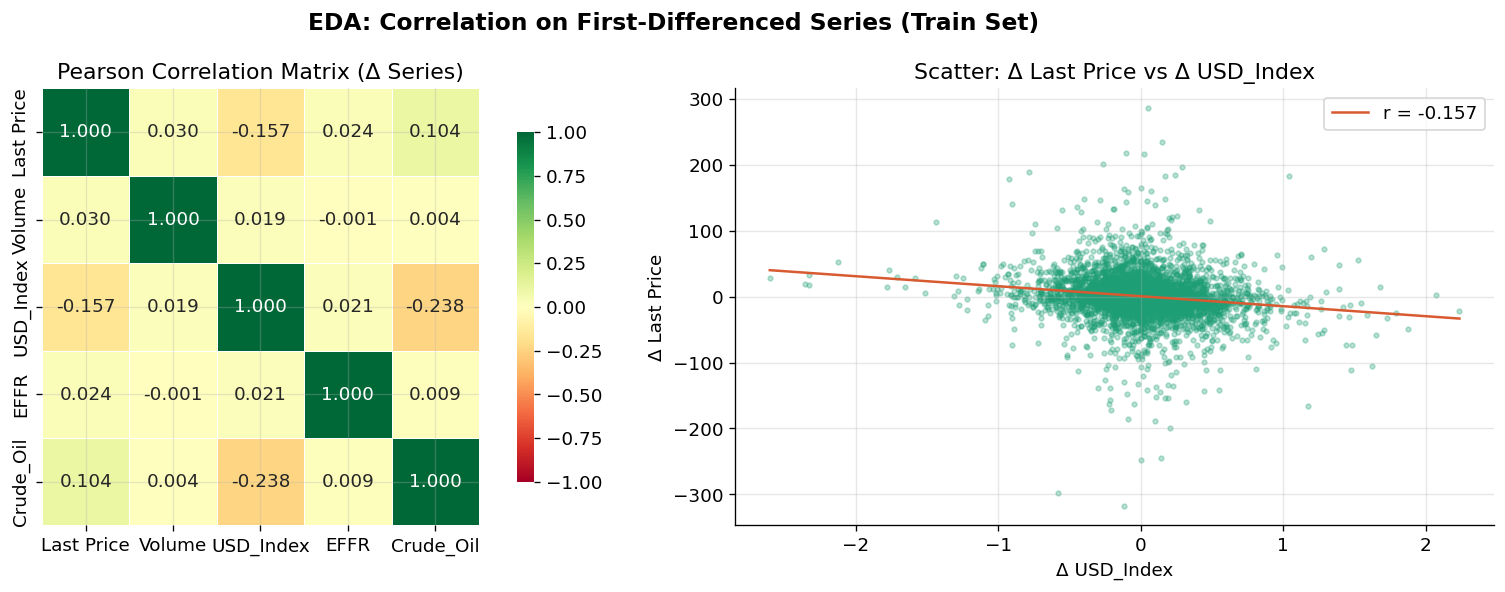


[Correlation on Δ series]
  ΔUSD_Index: r = -0.157
  ΔEFFR: r = 0.024
  ΔCrude_Oil: r = 0.104
  ΔVolume: r = 0.030


In [8]:
## 2.4 Correlation Analysis (First-Differenced Series)
numeric_cols = FEATURES
df_diff = df_eda[numeric_cols].diff().dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('EDA: Correlation on First-Differenced Series (Train Set)',
             fontsize=14, fontweight='bold')

corr = df_diff.corr()
sns.heatmap(corr, ax=axes[0], annot=True, fmt='.3f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, square=True, lw=0.5,
            cbar_kws={'shrink': 0.8})
axes[0].set_title('Pearson Correlation Matrix (Δ Series)')

best_col = corr['Last Price'].drop('Last Price').abs().idxmax()
axes[1].scatter(df_diff[best_col], df_diff['Last Price'],
                alpha=0.3, s=8, color=COLORS[1])
m, b, r, p, _ = stats.linregress(df_diff[best_col], df_diff['Last Price'])
xl = np.linspace(df_diff[best_col].min(), df_diff[best_col].max(), 100)
axes[1].plot(xl, m*xl+b, color=COLORS[3], lw=1.5, label=f'r = {r:.3f}')
axes[1].set_xlabel(f'Δ {best_col}'); axes[1].set_ylabel('Δ Last Price')
axes[1].set_title(f'Scatter: Δ Last Price vs Δ {best_col}')
axes[1].legend()

plt.tight_layout()
plt.savefig('eda_correlation.png', bbox_inches='tight', dpi=120)
plt.show()

print("\n[Correlation on Δ series]")
for col in ['USD_Index','EFFR','Crude_Oil','Volume']:
    print(f"  Δ{col}: r = {df_diff['Last Price'].corr(df_diff[col]):.3f}")

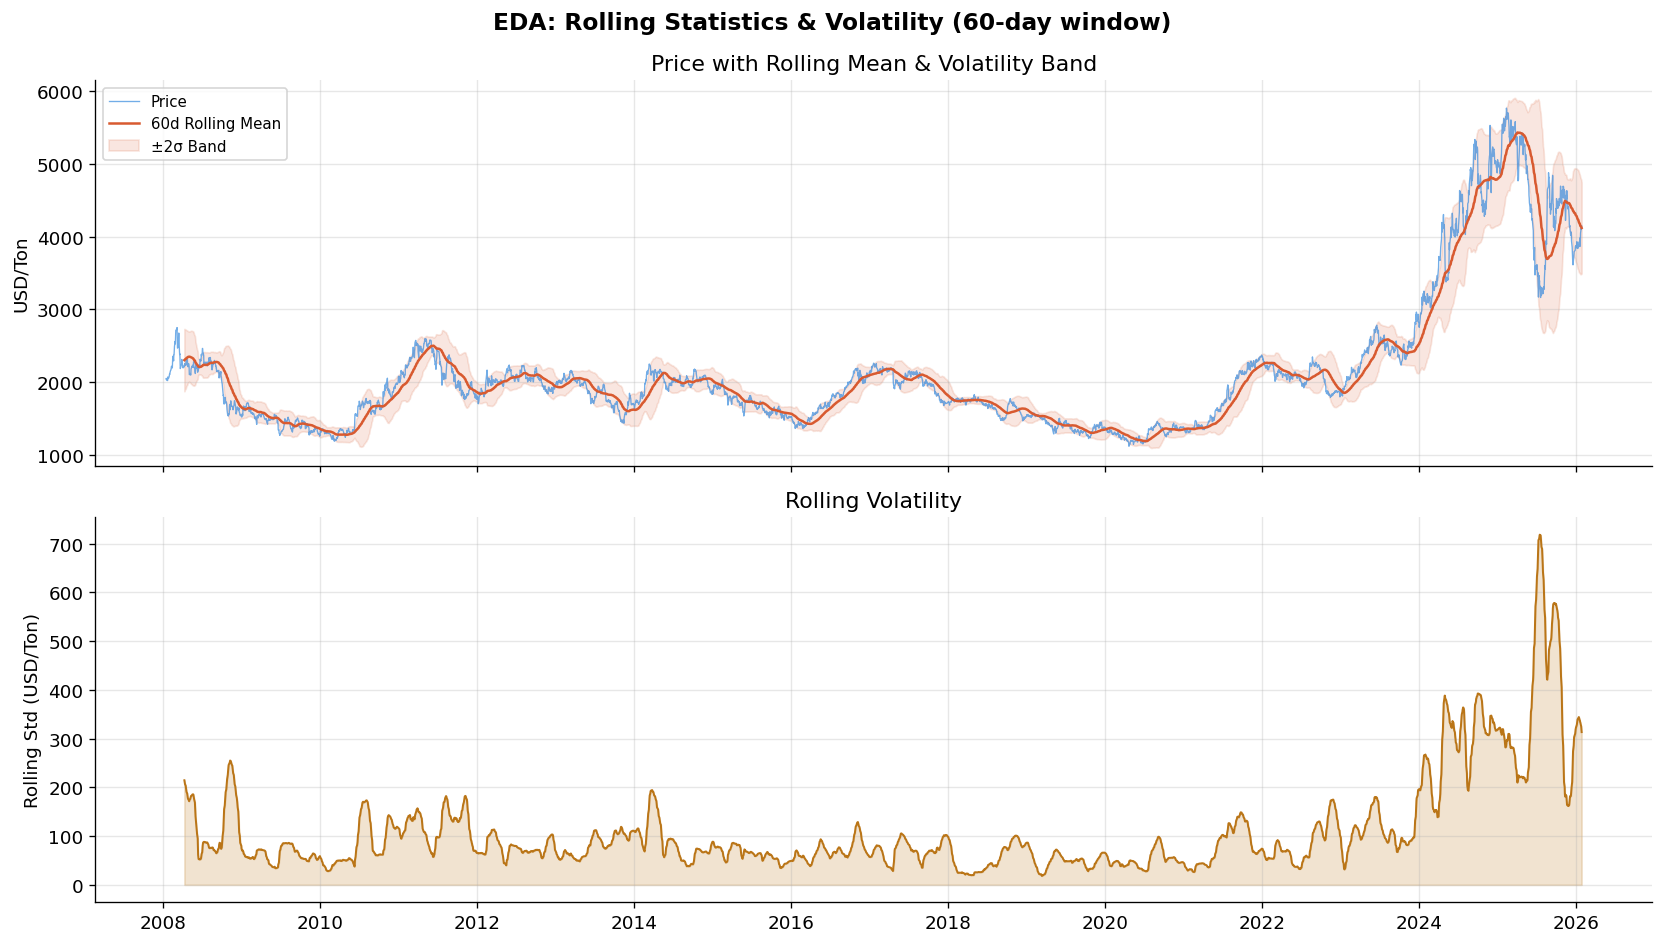


High-volatility days (top 20%): 909
Max rolling std: 718.1 USD/Ton


In [9]:
# 2.5 Rolling Statistics & Volatility
df_roll = df.set_index('Date').copy()
df_roll['Roll_Mean'] = df_roll['Last Price'].rolling(WINDOW).mean()
df_roll['Roll_Std']  = df_roll['Last Price'].rolling(WINDOW).std()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle('EDA: Rolling Statistics & Volatility (60-day window)',
             fontsize=14, fontweight='bold')

ax = axes[0]
ax.plot(df_roll.index, df_roll['Last Price'], color=COLORS[0], lw=0.8,
        alpha=0.7, label='Price')
ax.plot(df_roll.index, df_roll['Roll_Mean'], color=COLORS[3], lw=1.5,
        label='60d Rolling Mean')
ax.fill_between(df_roll.index,
                df_roll['Roll_Mean'] - 2*df_roll['Roll_Std'],
                df_roll['Roll_Mean'] + 2*df_roll['Roll_Std'],
                alpha=0.15, color=COLORS[3], label='±2σ Band')
ax.set_ylabel('USD/Ton')
ax.set_title('Price with Rolling Mean & Volatility Band')
ax.legend(fontsize=9)

ax = axes[1]
ax.plot(df_roll.index, df_roll['Roll_Std'], color=COLORS[2], lw=1.2)
ax.fill_between(df_roll.index, 0, df_roll['Roll_Std'], alpha=0.2, color=COLORS[2])
ax.set_ylabel('Rolling Std (USD/Ton)')
ax.set_title('Rolling Volatility')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('eda_rolling_stats.png', bbox_inches='tight', dpi=120)
plt.show()

high_vol = df_roll[df_roll['Roll_Std'] > df_roll['Roll_Std'].quantile(0.8)]
print(f"\nHigh-volatility days (top 20%): {len(high_vol)}")
print(f"Max rolling std: {df_roll['Roll_Std'].max():.1f} USD/Ton")

## 3. Data Preparation & Splits

In [ ]:
# 3.1 Temporal Split & Scaling
data      = df[FEATURES].values
dates_all = df['Date'].values

N_GROSS_ROWS = len(df) - TEST_SIZE                        
N_PURE_ROWS  = int(N_GROSS_ROWS * (1 - VAL_RATIO))        
N_VAL_ROWS   = N_GROSS_ROWS - N_PURE_ROWS                

pure_train_data = data[:N_PURE_ROWS]
val_data        = data[N_PURE_ROWS : N_PURE_ROWS + N_VAL_ROWS]
test_data       = data[N_PURE_ROWS + N_VAL_ROWS:]

pure_train_dates = dates_all[:N_PURE_ROWS]
val_dates        = dates_all[N_PURE_ROWS : N_PURE_ROWS + N_VAL_ROWS]
test_dates_raw   = dates_all[N_PURE_ROWS + N_VAL_ROWS:]

print("=== 3-WAY TEMPORAL SPLIT ===")
print(f"Pure Train : {len(pure_train_data):,} rows  "
      f"({pd.Timestamp(pure_train_dates[0]).date()} → "
      f"{pd.Timestamp(pure_train_dates[-1]).date()})")
print(f"Val Set    : {len(val_data):,} rows  "
      f"({pd.Timestamp(val_dates[0]).date()} → "
      f"{pd.Timestamp(val_dates[-1]).date()})")
print(f"Test Set   : {len(test_data):,} rows  "
      f"({pd.Timestamp(test_dates_raw[0]).date()} → "
      f"{pd.Timestamp(test_dates_raw[-1]).date()})")

scaler = MinMaxScaler(feature_range=(0, 1))
gross_train_data = data[:N_GROSS_ROWS]     
scaler.fit(gross_train_data)

pure_train_scaled = scaler.transform(pure_train_data)
val_scaled        = scaler.transform(val_data)
test_scaled       = scaler.transform(test_data)

df_eda = df.iloc[:N_PURE_ROWS].copy()

train_max = scaler.data_max_[0]
train_min = scaler.data_min_[0]
oor_days  = (data[N_PURE_ROWS + N_VAL_ROWS:, 0] > train_max).sum()
print(f"\nPure train price range : {train_min:.0f} — {train_max:.0f} USD/Ton")
print(f"Val set price range    : {val_data[:, 0].min():.0f} — "
      f"{val_data[:, 0].max():.0f} USD/Ton")
print(f"Test set price range   : {test_data[:, 0].min():.0f} — "
      f"{test_data[:, 0].max():.0f} USD/Ton")
print(f"Test days above train max: {oor_days}/300")

=== 3-WAY TEMPORAL SPLIT ===
Pure Train : 3,657 rows  (2008-01-14 → 2022-04-28)
Val Set    : 646 rows  (2022-04-29 → 2024-11-19)
Test Set   : 300 rows  (2024-11-20 → 2026-01-28)

Pure train price range : 1121 — 5334 USD/Tấn
Val set price range    : 1792 — 5334 USD/Tấn
Test set price range   : 3164 — 5765 USD/Tấn
Test days above train max: 56/300


In [ ]:
## 3.2 Sliding Window Sequences
full_scaled = np.vstack([pure_train_scaled, val_scaled, test_scaled])

def create_sequences(arr, window=WINDOW):
    X, y = [], []
    for i in range(window, len(arr)):
        X.append(arr[i-window:i])
        y.append(arr[i, 0])
    return np.array(X), np.array(y)

X_full, y_full = create_sequences(full_scaled)

n_pure  = N_PURE_ROWS - WINDOW       
n_val   = N_VAL_ROWS                 
n_test  = TEST_SIZE                  
n_gross = N_GROSS_ROWS - WINDOW      


X_train_dl = X_full[:n_pure]
y_train_dl = y_full[:n_pure]

X_val_dl   = X_full[n_pure : n_pure + n_val]
y_val_dl   = y_full[n_pure : n_pure + n_val]

X_test_dl  = X_full[n_pure + n_val:]
y_test_dl  = y_full[n_pure + n_val:]


X_train_ml = X_full[:n_gross][:, -1, :]
y_train_ml = y_full[:n_gross]

X_test_ml  = X_test_dl[:, -1, :]
y_test_ml  = y_test_dl

test_seq_dates = dates_all[N_PURE_ROWS + N_VAL_ROWS:]

print("=== SEQUENCE SHAPES ===")
print(f"X_train_dl : {X_train_dl.shape}")
print(f"X_val_dl   : {X_val_dl.shape}")
print(f"X_test_dl  : {X_test_dl.shape}")
print(f"X_train_ml : {X_train_ml.shape}")
print(f"X_test_ml  : {X_test_ml.shape}")
print(f"test_seq_dates: {len(test_seq_dates)}")

# Verify tất cả đều 300
assert X_test_dl.shape[0] == 300, f"X_test_dl sai: {X_test_dl.shape[0]}"
assert X_test_ml.shape[0] == 300, f"X_test_ml sai: {X_test_ml.shape[0]}"
assert len(test_seq_dates) == 300, f"test_seq_dates sai: {len(test_seq_dates)}"
print("✓ All test arrays = 300")

train_max = scaler.data_max_[0]
oor_days  = (data[N_PURE_ROWS + N_VAL_ROWS:, 0] > train_max).sum()
print(f"\nGross train (scaler fit) price range : {scaler.data_min_[0]:.0f} — {train_max:.0f} USD/Ton")
print(f"Val set price range                  : {val_data[:, 0].min():.0f} — {val_data[:, 0].max():.0f} USD/Ton")
print(f"Test set price range                 : {test_data[:, 0].min():.0f} — {test_data[:, 0].max():.0f} USD/Ton")
print(f"Test days above scaler-fit max: {oor_days}/300")

=== SEQUENCE SHAPES ===
X_train_dl : (3597, 60, 5)
X_val_dl   : (646, 60, 5)
X_test_dl  : (300, 60, 5)
X_train_ml : (4243, 5)   (Pure Train + Val gộp)
X_test_ml  : (300, 5)
test_seq_dates: 300
✓ All test arrays = 300

Gross train (scaler fit) price range : 1121 — 5334 USD/Tấn
Val set price range                  : 1792 — 5334 USD/Tấn
Test set price range                 : 3164 — 5765 USD/Tấn
Test days above scaler-fit max: 56/300


## 4. Machine Learning And Deep Learning Models


In [12]:
# 4.1 Helper Functions
def inverse_price(y_scaled):
    dummy = np.zeros((len(y_scaled), len(FEATURES)))
    dummy[:, 0] = y_scaled.flatten()
    return scaler.inverse_transform(dummy)[:, 0]

def evaluate(y_true_scaled, y_pred_scaled, model_name):
    y_true = inverse_price(y_true_scaled)
    y_pred = inverse_price(y_pred_scaled)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2   = r2_score(y_true, y_pred)
    print(f"  {model_name:<20} MAE={mae:7.2f}  RMSE={rmse:7.2f}  MAPE={mape:5.2f}%  R²={r2:+.3f}")
    return {'Model': model_name, 'MAE': mae, 'RMSE': rmse,
            'MAPE': mape, 'R2': r2, 'y_true': y_true, 'y_pred': y_pred}

def make_early_stop():
    return EarlyStopping(monitor='val_loss', patience=PATIENCE,
                         restore_best_weights=True, verbose=0)

results = {}
print("✓ 4.1 Helpers loaded.")

✓ 4.1 Helpers loaded.


In [13]:
## 4.2 Machine Learning Models (SVR, RF, XGB)
print("=== ML Model Training ===")

t0 = time.time()
svr = SVR(kernel='rbf', C=100, epsilon=0.01, gamma='scale')
svr.fit(X_train_ml, y_train_ml)
results['SVR'] = evaluate(y_test_ml, svr.predict(X_test_ml), 'SVR')

t0 = time.time()
rf = RandomForestRegressor(n_estimators=200, max_depth=10,
                           random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train_ml, y_train_ml)
results['RandomForest'] = evaluate(y_test_ml, rf.predict(X_test_ml), 'RandomForest')

t0 = time.time()
xgb = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6,
                   subsample=0.8, colsample_bytree=0.8,
                   random_state=RANDOM_STATE, verbosity=0)
xgb.fit(X_train_ml, y_train_ml)
results['XGBoost'] = evaluate(y_test_ml, xgb.predict(X_test_ml), 'XGBoost')

=== ML Model Training ===
  SVR                  MAE= 229.28  RMSE= 331.34  MAPE= 4.63%  R²=+0.771
  RandomForest         MAE= 169.39  RMSE= 232.09  MAPE= 3.47%  R²=+0.888
  XGBoost              MAE= 425.77  RMSE= 506.74  MAPE= 8.91%  R²=+0.465


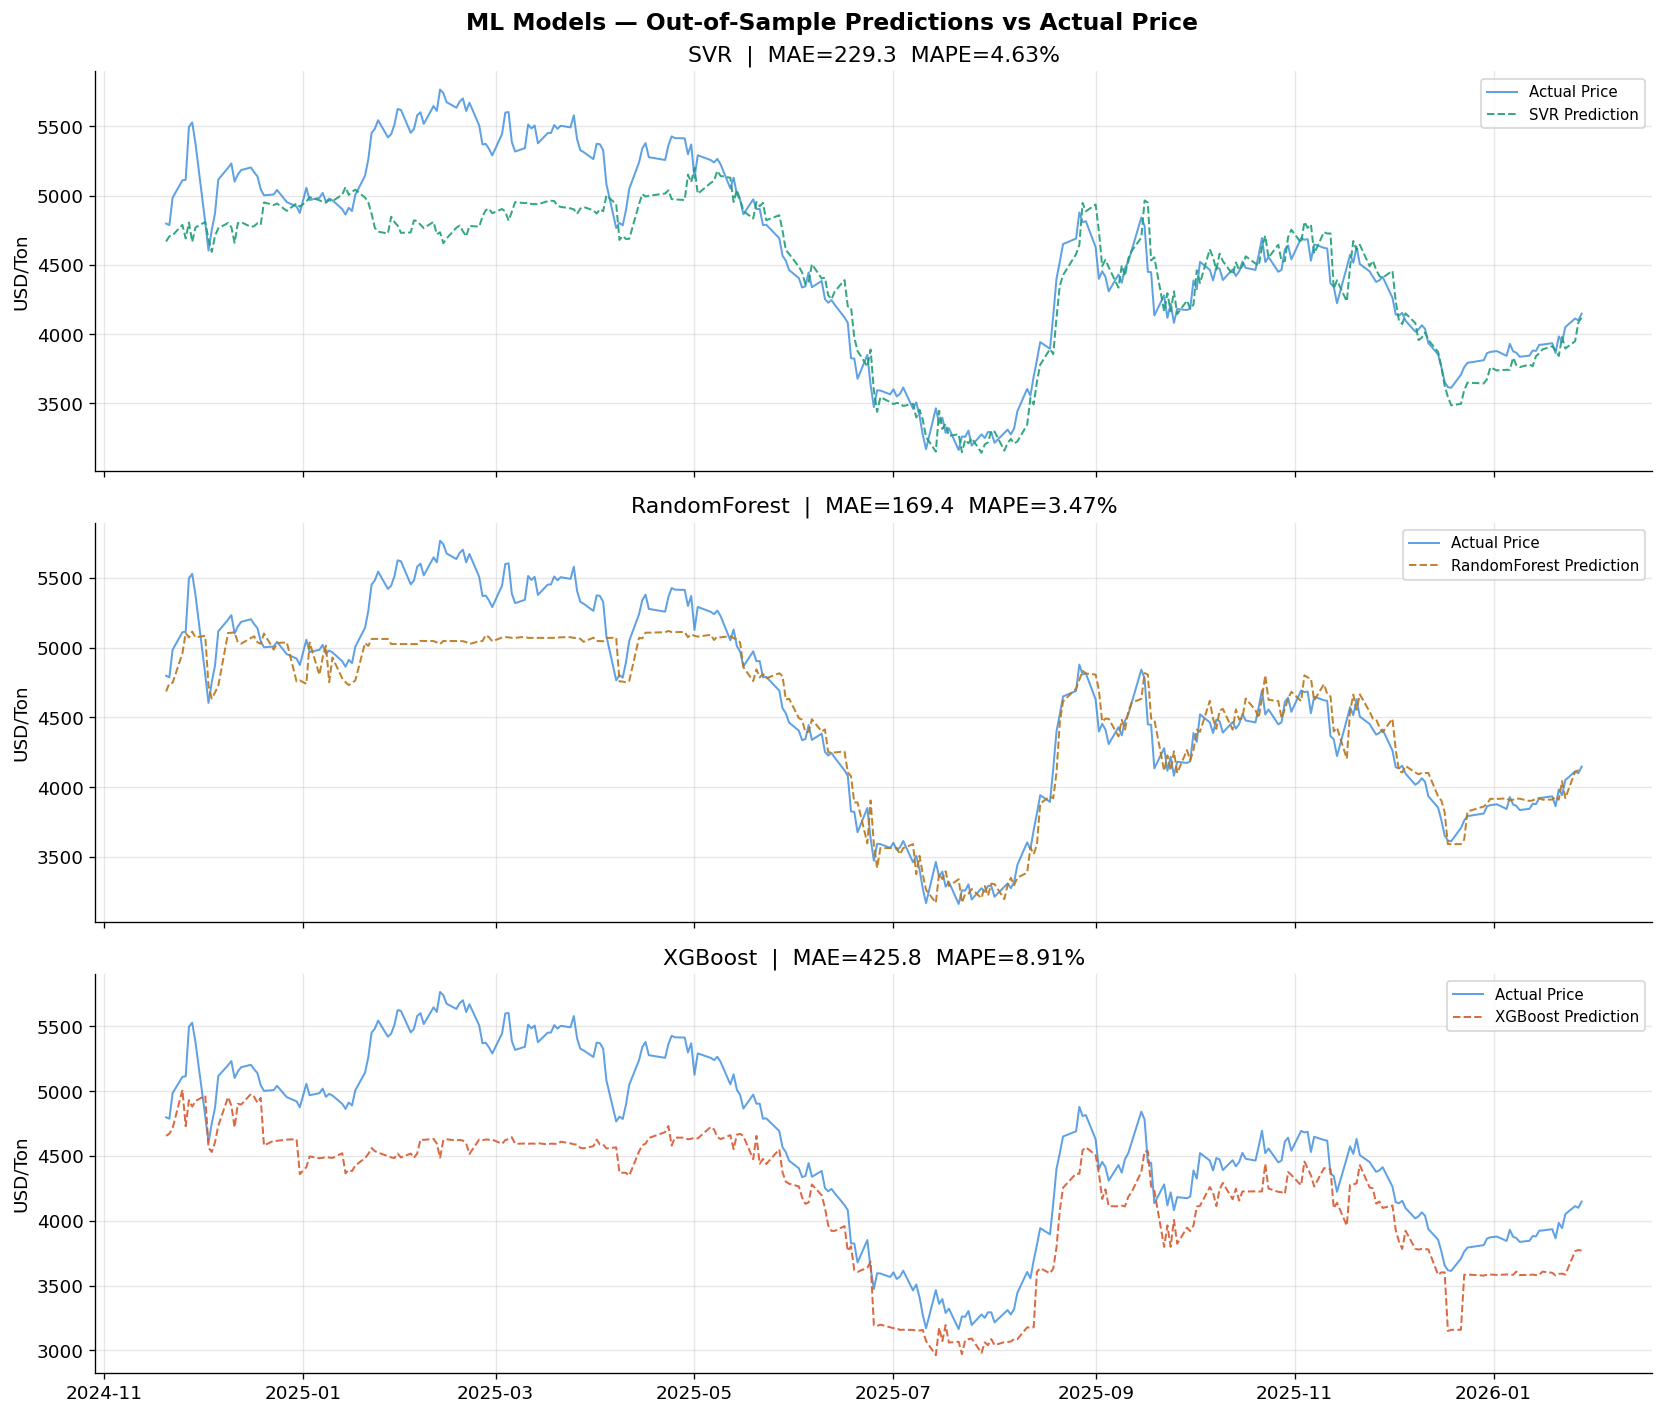

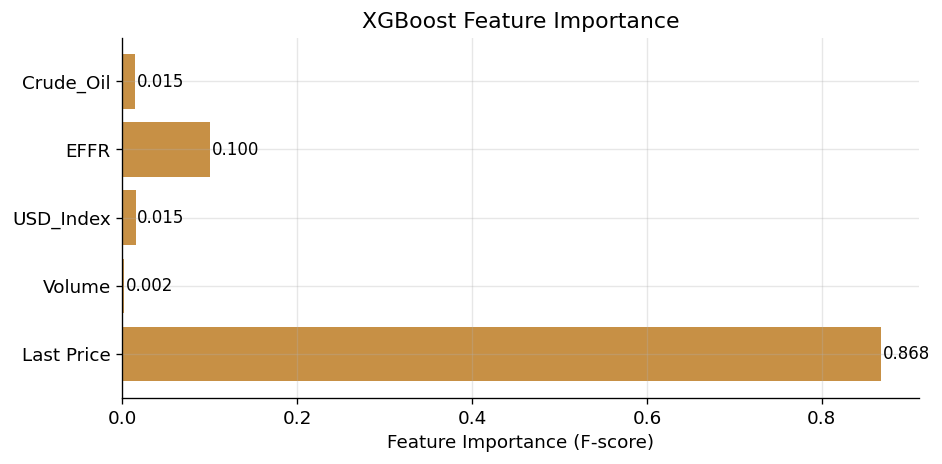

In [14]:
# 4.3 ML Predictions & Feature Importance
test_dates_plot = pd.to_datetime(test_seq_dates)   
actual_price    = results['SVR']['y_true']

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
fig.suptitle('ML Models — Out-of-Sample Predictions vs Actual Price', fontsize=14, fontweight='bold')
for i, name in enumerate(['SVR','RandomForest','XGBoost']):
    ax = axes[i]
    ax.plot(test_dates_plot, actual_price, color=COLORS[0], lw=1.2, alpha=0.8, label='Actual Price')
    ax.plot(test_dates_plot, results[name]['y_pred'], color=COLORS[i+1], lw=1.2, ls='--', alpha=0.9, label=f'{name} Prediction')
    ax.set_title(f"{name}  |  MAE={results[name]['MAE']:.1f}  MAPE={results[name]['MAPE']:.2f}%")
    ax.set_ylabel('USD/Ton')
    ax.legend(fontsize=9, loc='upper right')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.tight_layout()
plt.savefig('ml_predictions.png', bbox_inches='tight', dpi=120)
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
imps = xgb.feature_importances_
ax.barh(FEATURES, imps, color=COLORS[2], alpha=0.8)
ax.set_xlabel('Feature Importance (F-score)')
ax.set_title('XGBoost Feature Importance')
for i, v in enumerate(imps):
    ax.text(v+0.002, i, f'{v:.3f}', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('xgb_feature_importance.png', bbox_inches='tight', dpi=120)
plt.show()

In [15]:
# 4.4 DNN - Flat Control
print("=== DL Model Training ===")

X_train_dnn = X_train_dl.reshape(X_train_dl.shape[0], -1)
X_val_dnn   = X_val_dl.reshape(X_val_dl.shape[0], -1)
X_test_dnn  = X_test_dl.reshape(X_test_dl.shape[0], -1)

random.seed(RANDOM_STATE); np.random.seed(RANDOM_STATE); tf.random.set_seed(RANDOM_STATE)

dnn = Sequential([
    Input(shape=(WINDOW * len(FEATURES),)),
    Dense(128, activation='relu'), Dropout(0.2),
    Dense(64,  activation='relu'), Dropout(0.2),
    Dense(32,  activation='relu'), Dense(1)
], name='DNN')
dnn.compile(optimizer='adam', loss='mse')

h_dnn = dnn.fit(
    X_train_dnn, y_train_dl,
    validation_data=(X_val_dnn, y_val_dl),     
    epochs=EPOCHS, batch_size=BATCH,
    callbacks=[make_early_stop()], verbose=0    
)
results['DNN'] = evaluate(y_test_dl, dnn.predict(X_test_dnn, verbose=0).flatten(), 'DNN')

=== DL Model Training ===
  DNN                  MAE=1081.47  RMSE=1131.19  MAPE=23.23%  R²=-1.665


In [16]:
# 4.5 LSTM 
random.seed(RANDOM_STATE); np.random.seed(RANDOM_STATE); tf.random.set_seed(RANDOM_STATE)

lstm = Sequential([
    Input(shape=(WINDOW, len(FEATURES))),
    LSTM(128, return_sequences=True), Dropout(0.2),
    LSTM(64,  return_sequences=False), Dropout(0.2),
    Dense(32, activation='relu'), Dense(1)
], name='LSTM')
lstm.compile(optimizer='adam', loss='mse')

h_lstm = lstm.fit(
    X_train_dl, y_train_dl,
    validation_data=(X_val_dl, y_val_dl),      
    epochs=EPOCHS, batch_size=BATCH,
    callbacks=[make_early_stop()], verbose=0    
)
results['LSTM'] = evaluate(y_test_dl, lstm.predict(X_test_dl, verbose=0).flatten(), 'LSTM')

  LSTM                 MAE= 226.35  RMSE= 262.92  MAPE= 4.72%  R²=+0.856


In [17]:
# 4.6 GRU
random.seed(RANDOM_STATE); np.random.seed(RANDOM_STATE); tf.random.set_seed(RANDOM_STATE)

gru = Sequential([
    Input(shape=(WINDOW, len(FEATURES))),
    GRU(128, return_sequences=True), Dropout(0.2),
    GRU(64,  return_sequences=False), Dropout(0.2),
    Dense(32, activation='relu'), Dense(1)
], name='GRU')
gru.compile(optimizer='adam', loss='mse')

h_gru = gru.fit(
    X_train_dl, y_train_dl,
    validation_data=(X_val_dl, y_val_dl),      
    epochs=EPOCHS, batch_size=BATCH,
    callbacks=[make_early_stop()], verbose=0    
)
results['GRU'] = evaluate(y_test_dl, gru.predict(X_test_dl, verbose=0).flatten(), 'GRU')

  GRU                  MAE=  96.55  RMSE= 125.91  MAPE= 2.14%  R²=+0.967


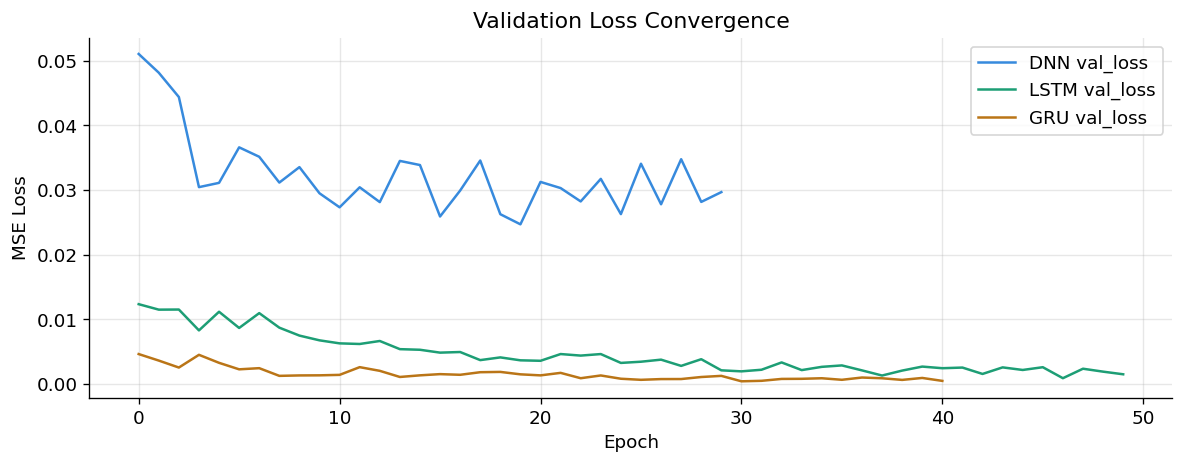

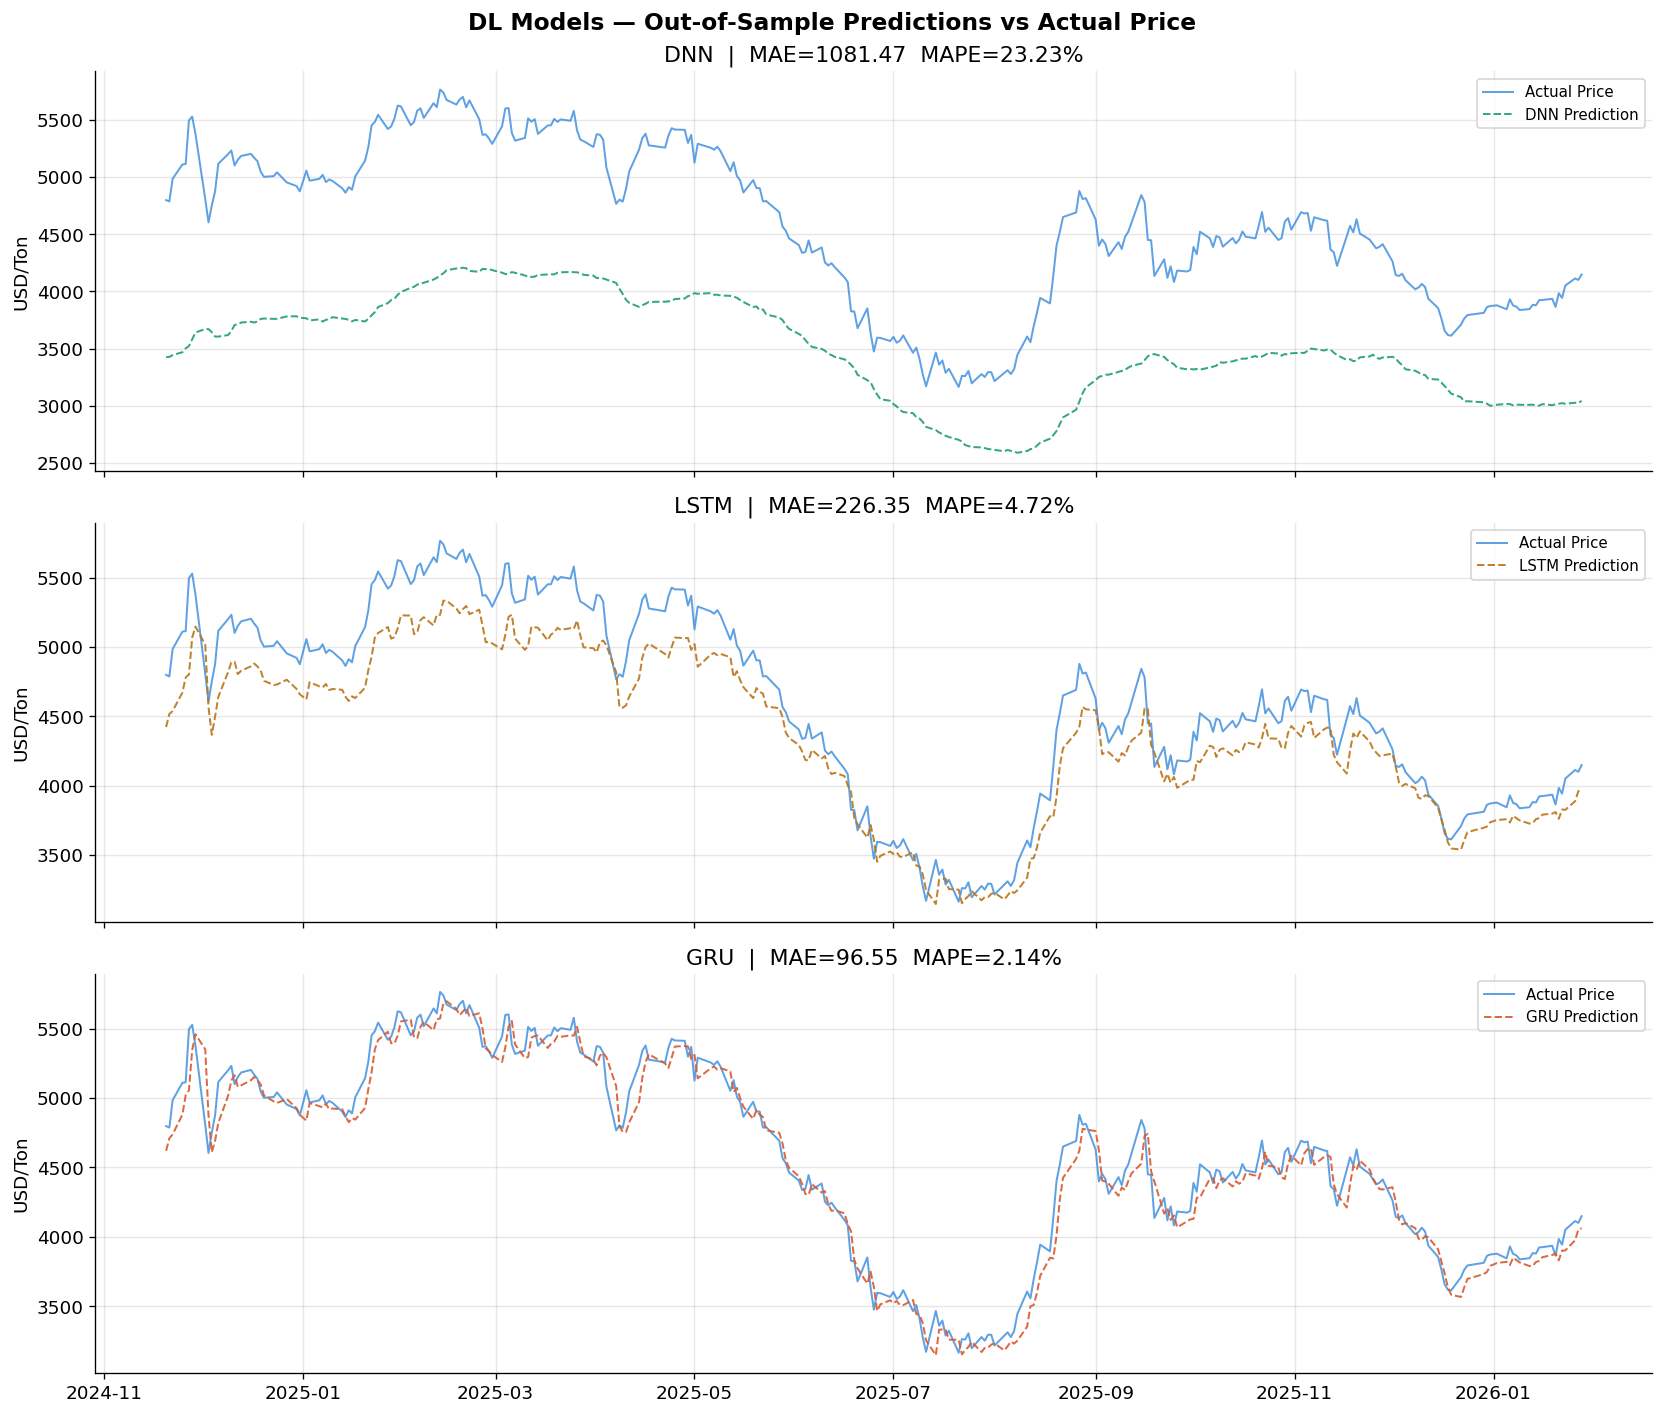

In [18]:
# 4.7 DL Training Convergence & Predictions
fig, ax = plt.subplots(figsize=(10, 4))
for i, (h, name) in enumerate(zip([h_dnn, h_lstm, h_gru], ['DNN','LSTM','GRU'])):
    ax.plot(h.history['val_loss'], color=COLORS[i], lw=1.5, label=f'{name} val_loss')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss')
ax.set_title('Validation Loss Convergence')
ax.legend()
plt.tight_layout()
plt.savefig('dl_training_loss.png', bbox_inches='tight', dpi=120)
plt.show()

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
fig.suptitle('DL Models — Out-of-Sample Predictions vs Actual Price', fontsize=14, fontweight='bold')
for i, name in enumerate(['DNN','LSTM','GRU']):
    ax = axes[i]
    ax.plot(test_dates_plot, actual_price, color=COLORS[0], lw=1.2, alpha=0.8, label='Actual Price')
    ax.plot(test_dates_plot, results[name]['y_pred'], color=COLORS[i+1], lw=1.2, ls='--', alpha=0.9, label=f'{name} Prediction')
    ax.set_title(f"{name}  |  MAE={results[name]['MAE']:.2f}  MAPE={results[name]['MAPE']:.2f}%")
    ax.set_ylabel('USD/Ton')
    ax.legend(fontsize=9, loc='upper right')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.tight_layout()
plt.savefig('dl_predictions.png', bbox_inches='tight', dpi=120)
plt.show()

## 5. Model Comparison & Statistical Tests

MODEL PERFORMANCE — Out-of-Sample (300 trading days)


,Group,MAE,RMSE,MAPE,R2
Model,,,,,
GRU,DL,96.55,125.91,2.14%,0.967
RandomForest,ML,169.39,232.09,3.47%,0.888
LSTM,DL,226.35,262.92,4.72%,0.856
SVR,ML,229.28,331.34,4.63%,0.771
XGBoost,ML,425.77,506.74,8.91%,0.465
DNN,DL,1081.47,1131.19,23.23%,-1.665


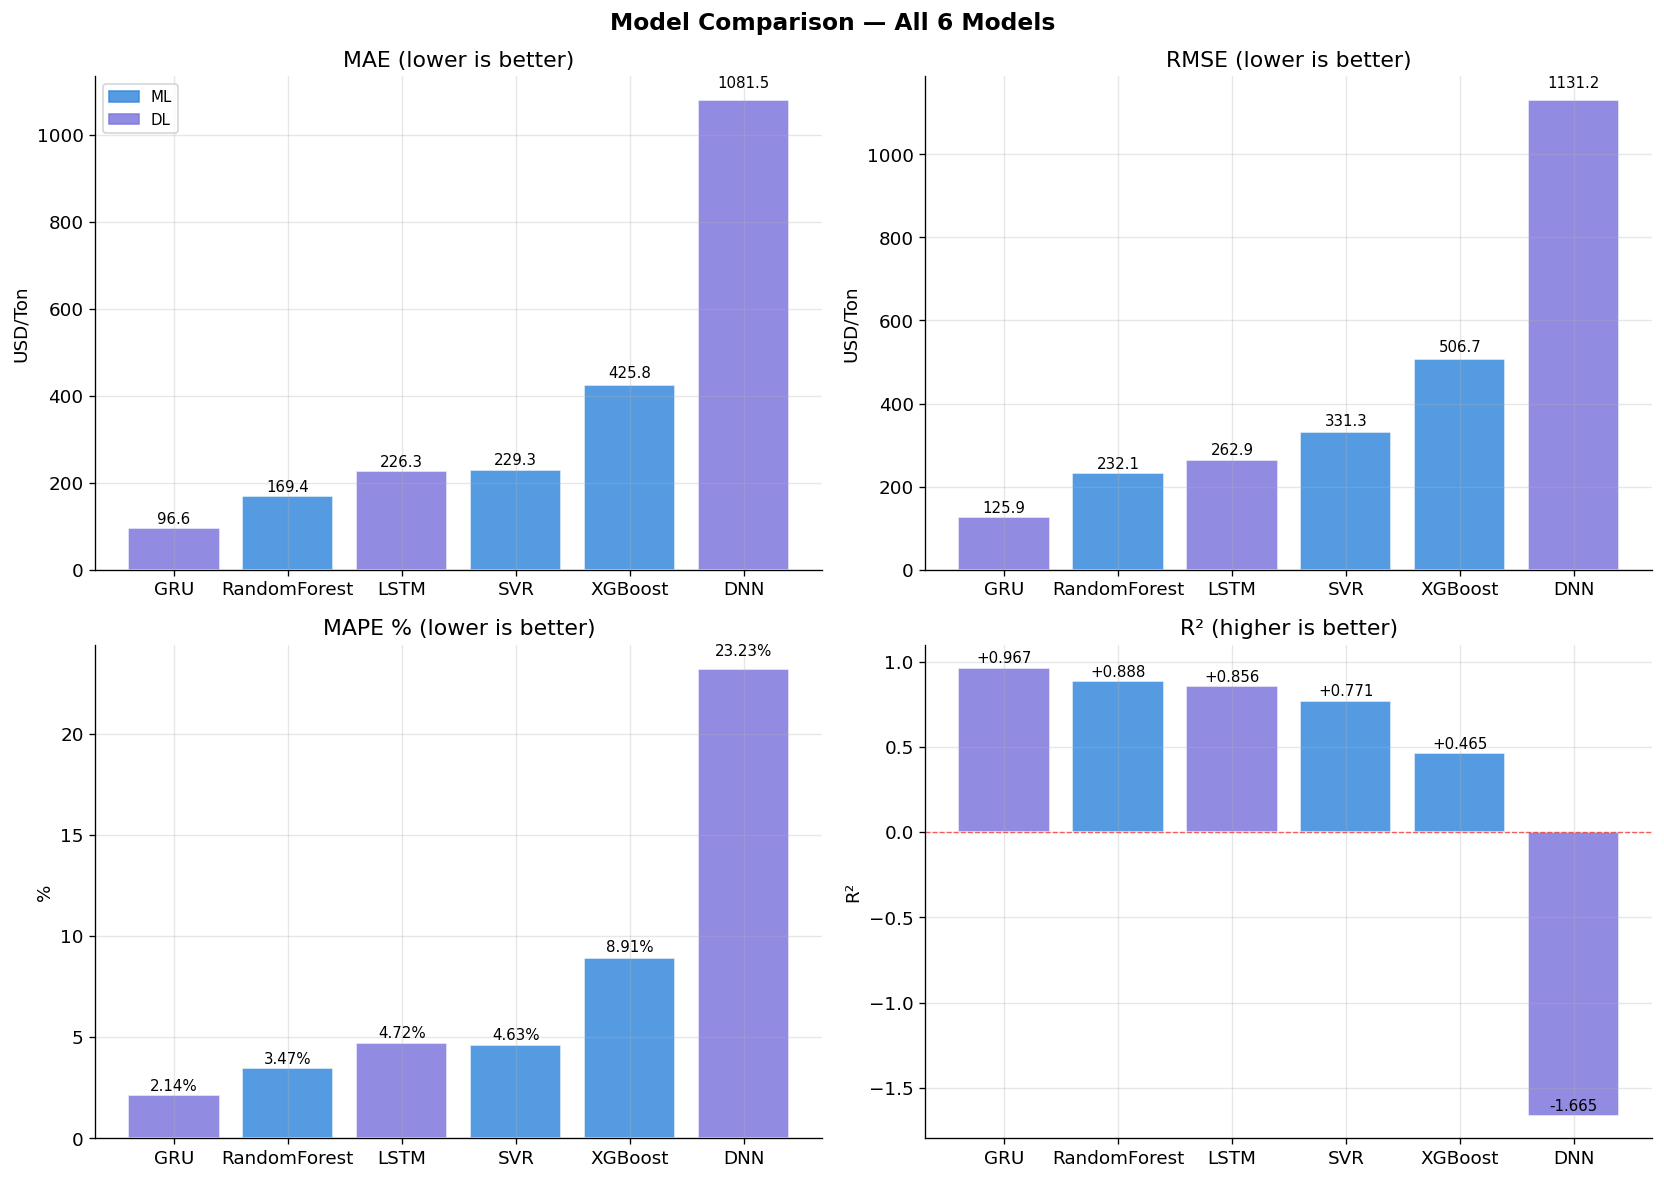

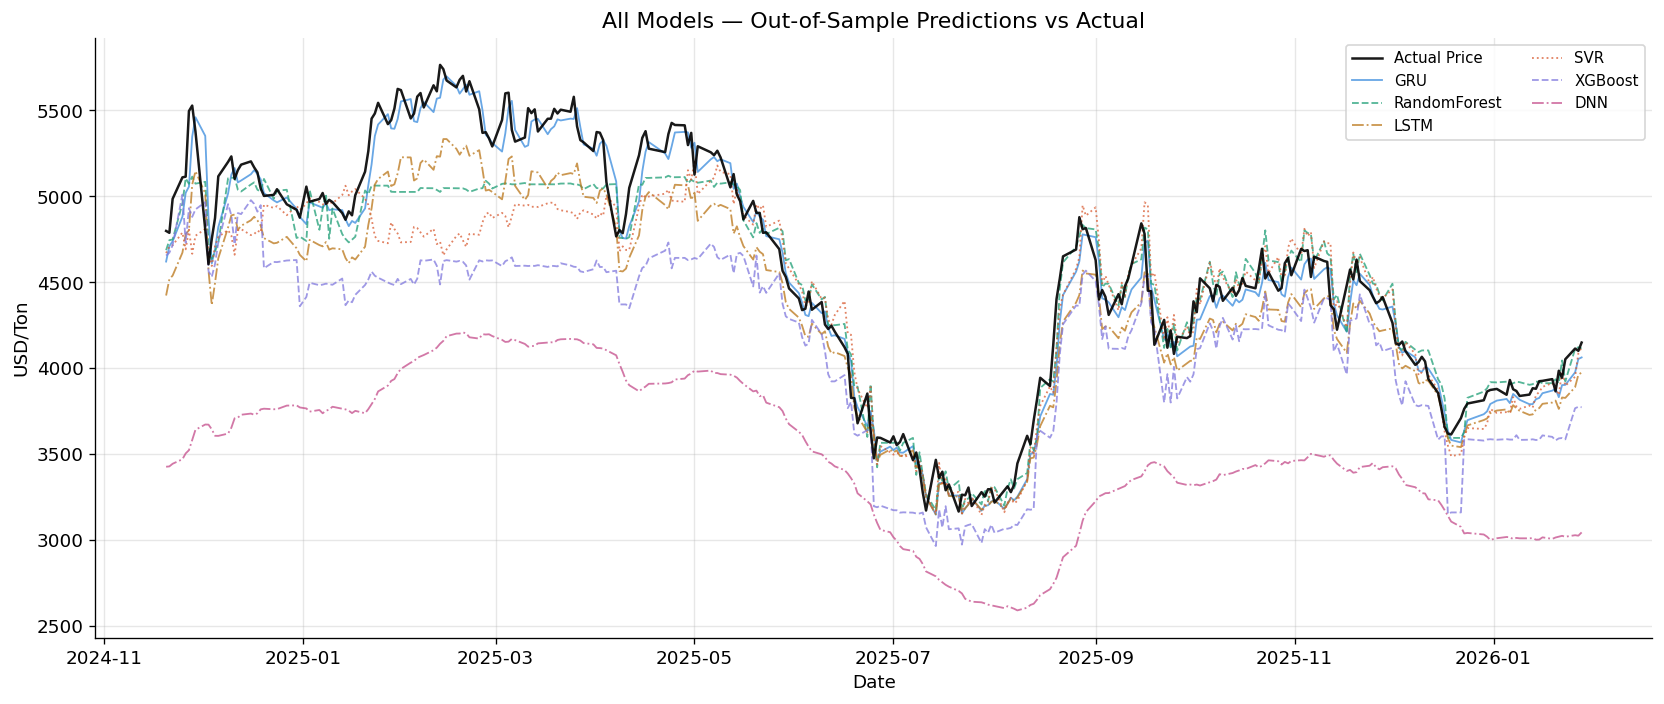

In [19]:
# 5.1 Performance Summary
metrics_df = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ['y_true','y_pred']}
    for r in results.values()
]).set_index('Model')

metrics_df['Group'] = ['ML','ML','ML','DL','DL','DL']
metrics_df = metrics_df[['Group','MAE','RMSE','MAPE','R2']].sort_values('MAE')

print("=" * 65)
print("MODEL PERFORMANCE — Out-of-Sample (300 trading days)")
print("=" * 65)
display(metrics_df.style
    .background_gradient(subset=['MAE','RMSE','MAPE'], cmap='RdYlGn_r')
    .background_gradient(subset=['R2'], cmap='RdYlGn')
    .format({'MAE':'{:.2f}','RMSE':'{:.2f}','MAPE':'{:.2f}%','R2':'{:.3f}'}))

best_model = metrics_df.index[0]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Model Comparison — All 6 Models', fontsize=14, fontweight='bold')
models_ord   = metrics_df.index.tolist()
group_colors = [COLORS[0] if metrics_df.loc[m,'Group']=='ML' else COLORS[4] for m in models_ord]

for ax, metric, title, ylabel in zip(axes.flat, ['MAE','RMSE','MAPE','R2'], 
        ['MAE (lower is better)','RMSE (lower is better)','MAPE % (lower is better)','R² (higher is better)'], 
        ['USD/Ton','USD/Ton','%','R²']):
    bars = ax.bar(models_ord, metrics_df[metric], color=group_colors, alpha=0.85, edgecolor='white')
    ax.set_title(title); ax.set_ylabel(ylabel)
    if metric == 'R2': ax.axhline(0, color='red', lw=0.8, ls='--', alpha=0.6)
    for bar, val in zip(bars, metrics_df[metric]):
        fmt = f'{val:.1f}' if metric in ['MAE','RMSE'] else f'{val:.2f}%' if metric == 'MAPE' else f'{val:+.3f}'
        offset = bar.get_height() * 0.02 if metric != 'R2' else 0.01
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+offset, fmt, ha='center', va='bottom', fontsize=9)

axes[0,0].legend(handles=[plt.Rectangle((0,0),1,1,color=COLORS[0],alpha=0.85), plt.Rectangle((0,0),1,1,color=COLORS[4],alpha=0.85)], labels=['ML','DL'], fontsize=9)
plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight', dpi=120)
plt.show()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(test_dates_plot, actual_price, color='black', lw=1.5, alpha=0.9, label='Actual Price', zorder=5)
for i, name in enumerate(models_ord):
    ax.plot(test_dates_plot, results[name]['y_pred'], color=COLORS[i % len(COLORS)], lw=1.1, ls=['-','--','-.',':', '--','-.'][i], alpha=0.75, label=name)
ax.set_title('All Models — Out-of-Sample Predictions vs Actual')
ax.set_xlabel('Date'); ax.set_ylabel('USD/Ton')
ax.legend(fontsize=9, ncol=2)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.tight_layout()
plt.savefig('all_models_comparison.png', bbox_inches='tight', dpi=120)
plt.show()

In [20]:
# 5.2 Diebold-Mariano Test (HAC, Andrews 1991 Bandwidth)
def diebold_mariano_test(y_true, pred1, pred2):
    e1 = y_true - pred1
    e2 = y_true - pred2
    d  = e1**2 - e2**2
    n  = len(d)
    d_mean = np.mean(d)
    bw = int(np.floor(4 * (n/100)**(2/9)))   
    gamma0 = np.var(d, ddof=1)
    nw_var  = gamma0
    for lag in range(1, bw+1):
        gamma_k = np.cov(d[lag:], d[:-lag], ddof=1)[0,1]
        nw_var += 2 * (1 - lag/(bw+1)) * gamma_k
    nw_var = max(nw_var, 1e-10)
    dm = d_mean / np.sqrt(nw_var / n)
    pv = 2 * (1 - scipy_stats.norm.cdf(abs(dm)))
    return dm, pv

y_true_orig = results[best_model]['y_true']
bw_used = int(np.floor(4 * (300/100)**(2/9)))
print(f"\n=== Diebold-Mariano Test  (NW bandwidth={bw_used}) ===")
for name in metrics_df.index:
    if name == best_model: continue
    dm, pv = diebold_mariano_test(y_true_orig,
                                  results[best_model]['y_pred'],
                                  results[name]['y_pred'])
    sig = "✓ Significant" if pv < 0.05 else "✗ Not significant"
    print(f"  {best_model} vs {name:<15}  DM={dm:+.3f}  p={pv:.4f}  {sig}")


=== Diebold-Mariano Test  (NW bandwidth=5) ===
  GRU vs RandomForest     DM=-3.123  p=0.0018  ✓ Significant
  GRU vs LSTM             DM=-7.615  p=0.0000  ✓ Significant
  GRU vs SVR              DM=-3.476  p=0.0005  ✓ Significant
  GRU vs XGBoost          DM=-5.633  p=0.0000  ✓ Significant
  GRU vs DNN              DM=-13.325  p=0.0000  ✓ Significant


## 6. Risk Management & Forecasting

Recursive forecast using: GRU  (RMSE_test=125.91 USD/Ton)

=== 7-Day Recursive Forecast (95% Expanding CI) ===
Horizon       Date  Forecast  Risk Floor  Risk Ceiling  Margin ±
    T+1 2026-01-29   4087.25     3840.46       4334.04    246.79
    T+2 2026-01-30   4049.11     3700.10       4398.13    349.01
    T+3 2026-02-02   4003.74     3576.28       4431.19    427.45
    T+4 2026-02-03   3960.02     3466.44       4453.60    493.58
    T+5 2026-02-04   3916.78     3364.94       4468.62    551.84
    T+6 2026-02-05   3873.64     3269.13       4478.15    604.51
    T+7 2026-02-06   3830.48     3177.53       4483.43    652.95


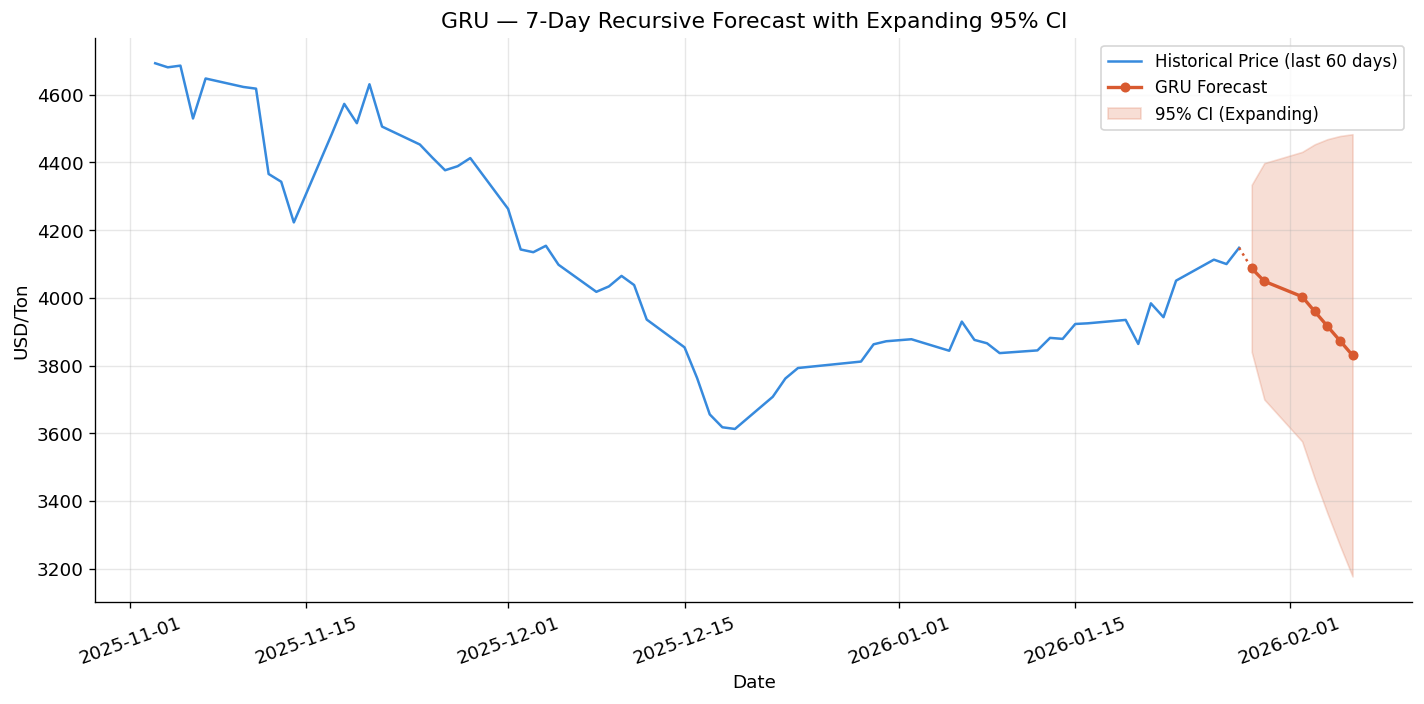

In [23]:
# 6.1 Recursive Multi-Step Forecast (7 Days)
model_map   = {'DNN': dnn, 'LSTM': lstm, 'GRU': gru}
best_overall = best_model if best_model in model_map else metrics_df[metrics_df['Group']=='DL'].index[0]
best_dl_model = model_map[best_overall]
RMSE_test     = metrics_df.loc[best_overall, 'RMSE']
Z95           = 1.96
HORIZON       = 7

print(f"Recursive forecast using: {best_overall}  (RMSE_test={RMSE_test:.2f} USD/Ton)")

last_window = full_scaled[-WINDOW:].copy()
last_date   = pd.Timestamp(dates_all[-1])

forecasts = []
for step in range(HORIZON):
    inp = last_window[np.newaxis, :, :]              
    pred_scaled = best_dl_model.predict(inp, verbose=0)[0, 0]

    dummy = np.zeros((1, len(FEATURES)))
    dummy[0, 0] = pred_scaled
    pred_price = scaler.inverse_transform(dummy)[0, 0]

    margin = Z95 * RMSE_test * np.sqrt(step + 1)
    forecasts.append({
        'Horizon':      f'T+{step+1}',
        'Date':         (last_date + pd.offsets.BDay(step+1)).date(),
        'Forecast':     round(pred_price, 2),
        'Risk Floor':   round(pred_price - margin, 2),
        'Risk Ceiling': round(pred_price + margin, 2),
        'Margin ±':     round(margin, 2),
    })
    new_row = last_window[-1].copy()
    new_row[0] = pred_scaled
    last_window = np.vstack([last_window[1:], new_row])

forecast_df = pd.DataFrame(forecasts)
print("\n=== 7-Day Recursive Forecast (95% Expanding CI) ===")
print(forecast_df.to_string(index=False))   

fig, ax = plt.subplots(figsize=(12, 6))
context_dates  = pd.to_datetime(dates_all[-60:])
context_prices = data[-60:, 0]
ax.plot(context_dates, context_prices, color=COLORS[0], lw=1.5, label='Historical Price (last 60 days)')

fd = pd.to_datetime(forecast_df['Date'])
ax.plot(fd, forecast_df['Forecast'], color=COLORS[3], lw=2, marker='o', ms=5, label=f'{best_overall} Forecast')
ax.fill_between(fd, forecast_df['Risk Floor'], forecast_df['Risk Ceiling'], alpha=0.2, color=COLORS[3], label='95% CI (Expanding)')
ax.plot([context_dates[-1], fd.iloc[0]], [context_prices[-1], forecast_df['Forecast'].iloc[0]], color=COLORS[3], lw=1.5, ls=':')

ax.set_title(f'{best_overall} — 7-Day Recursive Forecast with Expanding 95% CI')
ax.set_xlabel('Date'); ax.set_ylabel('USD/Ton')
ax.legend(fontsize=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('recursive_forecast.png', bbox_inches='tight', dpi=120)
plt.show()

## 7. Robustness Check

In [22]:
# 7.1 Multi-Seed Evaluation (Validation Loss Monitor)
SEEDS = [0, 7, 21, 42, 99]

def build_model(arch, seed):
    random.seed(seed); np.random.seed(seed); tf.random.set_seed(seed)
    m = Sequential(name=f'{arch}_s{seed}')
    m.add(Input(shape=(WINDOW, len(FEATURES))))
    if arch == 'LSTM':
        m.add(LSTM(128, return_sequences=True)); m.add(Dropout(0.2))
        m.add(LSTM(64,  return_sequences=False))
    else:
        m.add(GRU(128, return_sequences=True)); m.add(Dropout(0.2))
        m.add(GRU(64,  return_sequences=False))
    m.add(Dropout(0.2)); m.add(Dense(32, activation='relu')); m.add(Dense(1))
    m.compile(optimizer='adam', loss='mse')
    return m

def robustness_check(arch, seeds):
    rows = []
    print(f"\n--- Robustness Check: {arch} ---")
    for seed in seeds:
        m = build_model(arch, seed)
        m.fit(X_train_dl, y_train_dl, validation_data=(X_val_dl, y_val_dl), epochs=50, batch_size=32, callbacks=[make_early_stop()], verbose=0)
        y_pred = inverse_price(m.predict(X_test_dl, verbose=0).flatten())
        y_true = inverse_price(y_test_dl)
        mae = mean_absolute_error(y_true, y_pred)
        r2  = r2_score(y_true, y_pred)
        rows.append({'Seed': seed, 'MAE': mae, 'R2': r2})
        print(f"  Seed {seed:2d} → MAE={mae:.2f}  R²={r2:.4f}")
    df_r = pd.DataFrame(rows)
    return {
        'Model':    arch,
        'MAE Mean': df_r['MAE'].mean(),
        'MAE Std':  df_r['MAE'].std(),
        'R² Mean':  df_r['R2'].mean(),
        'R² Std':   df_r['R2'].std(),
        'CV(MAE)':  df_r['MAE'].std() / df_r['MAE'].mean() * 100
    }

lstm_rob = robustness_check('LSTM', SEEDS)
gru_rob  = robustness_check('GRU',  SEEDS)

rob_df = pd.DataFrame([lstm_rob, gru_rob]).round(4)
print("\n=== Table 3.6: Multi-Seed Robustness Results ===")
display(rob_df)

for row in [lstm_rob, gru_rob]:
    stable = "✓ STABLE" if row['CV(MAE)'] < 15 else "⚠ UNSTABLE"
    print(f"  {row['Model']}: CV(MAE)={row['CV(MAE)']:.2f}%  {stable}")


--- Robustness Check: LSTM ---
  Seed  0 → MAE=131.93  R²=0.9437
  Seed  7 → MAE=211.95  R²=0.8771
  Seed 21 → MAE=353.71  R²=0.6321
  Seed 42 → MAE=226.35  R²=0.8560
  Seed 99 → MAE=376.92  R²=0.5987

--- Robustness Check: GRU ---
  Seed  0 → MAE=154.14  R²=0.9141
  Seed  7 → MAE=101.33  R²=0.9640
  Seed 21 → MAE=97.54  R²=0.9659
  Seed 42 → MAE=96.55  R²=0.9670
  Seed 99 → MAE=151.40  R²=0.9229

=== Table 3.6: Multi-Seed Robustness Results ===


,Model,MAE Mean,MAE Std,R² Mean,R² Std,CV(MAE)
0,LSTM,260.1722,102.8289,0.7815,0.1555,39.5234
1,GRU,120.1925,29.8107,0.9468,0.0260,24.8025


  LSTM: CV(MAE)=39.52%  ⚠ UNSTABLE
  GRU: CV(MAE)=24.80%  ⚠ UNSTABLE
